In [1]:
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2

# Put the project root and src/ on the path so the modules below import
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import features
import utilities
import model

from theme import set_theme
set_theme()

{'rc_params': {'figure.facecolor': '#282c34',
  'axes.facecolor': '#282c34',
  'savefig.facecolor': '#282c34',
  'axes.edgecolor': '#3e4451',
  'axes.labelcolor': '#abb2bf',
  'text.color': '#abb2bf',
  'xtick.color': '#abb2bf',
  'ytick.color': '#abb2bf',
  'axes.grid': True,
  'grid.color': '#3e4451',
  'grid.linewidth': 0.6,
  'grid.linestyle': '-',
  'font.size': 9},
 'palette': ['#61afef', '#98c379', '#e5c07b', '#d19a66', '#c678dd', '#e06c75']}

In [2]:
path = ROOT / "data" / "processed" / "feature_df_processed.parquet"

df = pd.read_parquet(path)
df.columns

Index(['expiry', 'trade_date', 'contract', 'expiry_month',
       'safex_zar_per_tonne', 'safex_volume', 'safex_open_interest',
       'cbot_usd_per_tonne', 'usdzar', 'safex_usd_per_tonne', 'ym_corn_arb',
       'yw_spread', 'yw_z', 'wm_zar_per_tonne', 'wm_usd_per_tonne',
       'log_safex_zar_per_tonne', 'ret_safex_zar_per_tonne',
       'clog_safex_zar_per_tonne', 'log_safex_usd_per_tonne',
       'ret_safex_usd_per_tonne', 'clog_safex_usd_per_tonne',
       'log_cbot_usd_per_tonne', 'ret_cbot_usd_per_tonne',
       'clog_cbot_usd_per_tonne', 'log_wm_zar_per_tonne',
       'ret_wm_zar_per_tonne', 'clog_wm_zar_per_tonne', 'log_wm_usd_per_tonne',
       'ret_wm_usd_per_tonne', 'clog_wm_usd_per_tonne', 'log_usdzar',
       'ret_usdzar', 'clog_usdzar', 'ret_ym_corn_arb', 'c_ym_corn_arb',
       'ret_yw_spread', 'c_yw_spread', 'hedge_beta_v2', 'c_arb_hedged_v2',
       'c_arb_hedged_v2_lag1', 'c_arb_hedged_v2_ma_20',
       'c_arb_hedged_v2_ma_dist_z_20', 'c_arb_hedged_v2_ma_200',
       

In [3]:
ret_df = df[["ret_safex_zar_per_tonne", "ret_safex_usd_per_tonne", "ret_wm_zar_per_tonne", "ret_wm_usd_per_tonne", "log_safex_zar_per_tonne", "log_safex_usd_per_tonne", "safex_volume", "safex_open_interest", "ret_ym_corn_arb", "ret_yw_spread"]]
ret_df.tail()

,ret_safex_zar_per_tonne,ret_safex_usd_per_tonne,ret_wm_zar_per_tonne,ret_wm_usd_per_tonne,log_safex_zar_per_tonne,log_safex_usd_per_tonne,safex_volume,safex_open_interest,ret_ym_corn_arb,ret_yw_spread
dt,,,,,,,,,,
2026-08-26,0.022748,0.026696,0.020378,0.024327,8.305484,5.537556,1733,21106,1.673157,-9.0
2026-08-27,0.000247,-0.004672,-0.001970,-0.006889,8.305731,5.532884,1676,21245,-3.644653,-9.0
2026-08-28,0.020302,0.021276,0.026513,0.027487,8.326033,5.554160,2503,21483,3.370790,26.0
2026-08-31,0.020847,0.012228,0.018785,0.010167,8.346879,5.566387,3550,21839,4.358954,-8.0
2026-09-01,-0.014571,-0.015828,-0.025288,-0.026544,8.332308,5.550560,2823,21805,-4.204572,-45.0


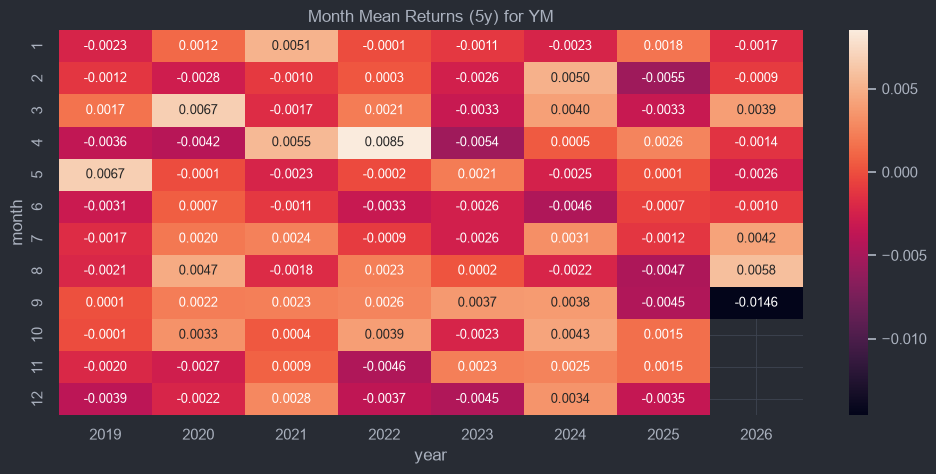

     ret_safex_zar_per_tonne                              
                        mean       std      skew      kurt
dt                                                        
2019               -0.000922  0.012662  0.298797  0.731386
2020                0.000860  0.012588 -0.015483  0.102619
2021                0.000897  0.015948 -0.186001  0.114897
2022                0.000597  0.013170 -0.124260  0.213478
2023               -0.001272  0.014038  0.190182  0.753564
2024                0.001278  0.011117  0.203224  0.258459
2025               -0.001316  0.012389  0.105374 -0.022892
2026                0.000882  0.014591 -0.072099  0.279443


In [4]:
# check return seasonality by day of week, month
ret_df["day_of_week"] = ret_df.index.dayofweek
ret_df["month"] = ret_df.index.month
ret_df["year"] = ret_df.index.year

# filter for last 5 years
current = ret_df.loc["2019": "2026"]

# group
pivoted = current.pivot_table(values="ret_safex_zar_per_tonne", index="month", columns="year").round(4)

# Monthly mean returns for year - filtered to the last 5 years
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivoted, annot=True, fmt=".4f")
ax.set(title=("Month Mean Returns (5y) for YM"))
plt.show()

# What is the distribution of mean, std, skew and kurtosis
print(current.groupby(current.index.year).aggregate({"ret_safex_zar_per_tonne": ["mean", "std", "skew", pd.Series.kurtosis]}))

# Regime study — YM

**The question.** Does YM trade in a handful of distinct market states that come back again and again — a quiet state, a squeeze state, a harvest-pressure state — and can we tell which one we are in reliably enough to position differently in each?

**Why it matters for the book.** We trade the arb both ways. YM is one leg of it. If YM tends to run hard in a particular state or a particular month, then selling YM against corn in that window is dangerous — the arb can open further before it comes back. The reverse is also true: there are windows where the arb reliably grinds in and buying it is the exposed side.

**What this is not.** This is a description of the market's states, not a forecast of the next one. There is no switching model here and nothing that predicts tomorrow.

**The state descriptors.** Six measures of what kind of market we are in, all computed from data available on the day:

| | measures |
|---|---|
| `log_vol` | how violent the market is |
| `vol_ratio` | whether volatility is building or fading |
| `trend_z` | how strong the directional drift is, relative to the noise |
| `var_ratio` | whether moves compound or reverse — trend market or chop |
| `arb_pctl` | where local price sits between export parity and import parity |
| `cbot_corr` | whether the market is being driven by Chicago or by local fundamentals |

The last two matter most. Local price pinned at import parity is a fundamentally different market from local price at export parity, no matter what volatility happens to be doing.

**One deliberate omission.** The calendar is not an input. Feeding the month in would force the states to become calendar buckets and destroy the only interesting question — whether they line up with the season on their own.

In [28]:
import regimes as rg

prep = rg.prepare_returns(df, "ret_safex_zar_per_tonne")
rets = prep["returns"]
X = rg.build_regime_features(df)
diag = rg.feature_diagnostics(X)

print(f"roll-gap days zero-filled: {prep['n_gaps']} of {prep['n_obs']} ({prep['gap_fraction']:.1%})")
print(f"feature matrix: {X.shape[0]} days x {X.shape[1]} descriptors, "
      f"{X.index.min():%Y-%m-%d} to {X.index.max():%Y-%m-%d}")
print(f"max correlation between descriptors: {diag['max_abs_correlation']:.2f} {diag['worst_pair']}")
display(X.describe().T.round(3))
display(diag["correlation"])

roll-gap days zero-filled: 45 of 3947 (1.1%)
feature matrix: 3696 days x 6 descriptors, 2011-06-20 to 2026-09-01
max correlation between descriptors: 0.31 ('trend_z', 'arb_pctl')


,count,mean,std,min,25%,50%,75%,max
log_vol,3696.0,-1.563,0.202,-2.211,-1.702,-1.538,-1.418,-1.086
vol_ratio,3696.0,-0.037,0.194,-0.853,-0.150,-0.020,0.102,0.396
trend_z,3696.0,0.142,1.117,-4.157,-0.572,0.144,0.843,3.951
var_ratio,3696.0,1.013,0.250,0.460,0.831,0.988,1.167,2.035
arb_pctl,3696.0,0.570,0.322,0.001,0.312,0.610,0.886,1.000
cbot_corr,3696.0,0.571,0.186,0.064,0.456,0.599,0.705,0.899


,log_vol,vol_ratio,trend_z,var_ratio,arb_pctl,cbot_corr
log_vol,1.000,-0.047,0.043,-0.071,-0.195,0.252
vol_ratio,-0.047,1.000,0.070,0.028,0.001,-0.055
trend_z,0.043,0.070,1.000,-0.017,0.313,0.027
var_ratio,-0.071,0.028,-0.017,1.000,-0.111,-0.065
arb_pctl,-0.195,0.001,0.313,-0.111,1.000,-0.243
cbot_corr,0.252,-0.055,0.027,-0.065,-0.243,1.000


## How many states are there?

The standard way to choose the number of states is to let a statistical criterion pick it. That criterion assumes every day is a fresh, independent observation — which is badly wrong here. These descriptors are built from one-to-three month windows, so today's reading is almost the same as yesterday's. Fifteen years of daily data does not contain fifteen years' worth of independent information about market state.

The chart below shows both versions. On the left, the naive count, which happily justifies eight separate states. In the middle, the same criterion corrected for how much genuinely independent information is present. On the right, a direct measure of how cleanly separated the states are — above the dashed line means real separation, below it means we are slicing one continuous blob into arbitrary pieces.

3696 days of data contain roughly 30 independent observations
preferred number of states, corrected:  1
preferred number of states, naive:      8


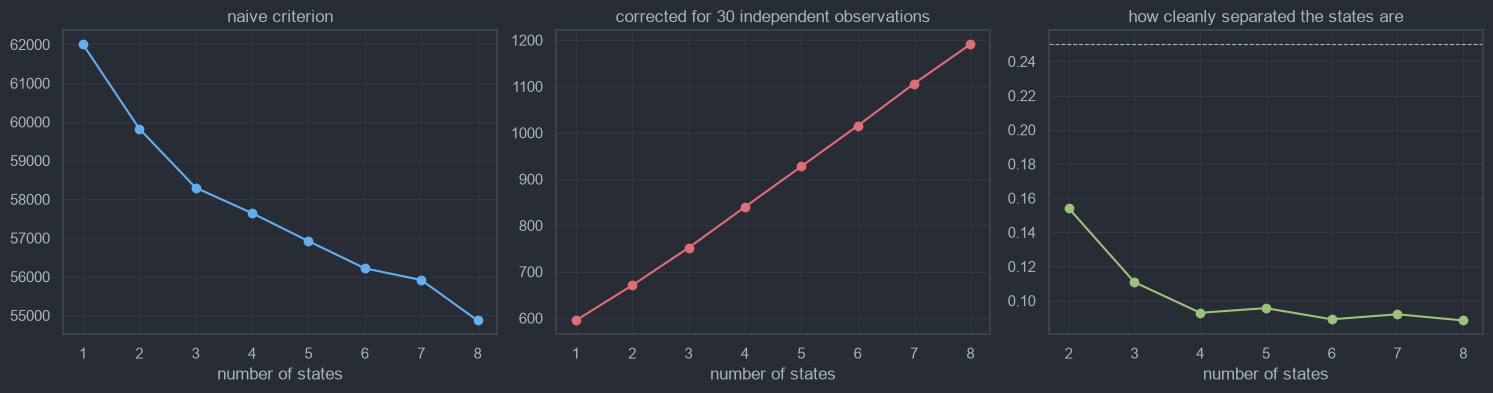

In [29]:
ess = rg.effective_sample_size(X)
selection = rg.select_n_components(X, n_effective=ess["n_effective"])
table = selection["table"]
raw_best = table.loc[table["bic"].idxmin()]

print(f"{ess['n_rows']} days of data contain roughly {ess['n_effective']:.0f} independent observations")
print(f"preferred number of states, corrected:  {selection['best_k']}")
print(f"preferred number of states, naive:      {int(raw_best['k'])}")

best_per_k = table.loc[table.groupby("k")["bic"].idxmin()].set_index("k")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(best_per_k.index, best_per_k["bic"], marker="o", color="#61afef")
axes[0].set(title="naive criterion", xlabel="number of states")
axes[1].plot(best_per_k.index, best_per_k["bic_eff"], marker="o", color="#e06c75")
axes[1].set(title=f"corrected for {ess['n_effective']:.0f} independent observations",
            xlabel="number of states")
axes[2].plot(best_per_k.index[1:], best_per_k["silhouette"].iloc[1:], marker="o", color="#98c379")
axes[2].axhline(0.25, ls="--", color="#abb2bf", lw=0.8)
axes[2].set(title="how cleanly separated the states are", xlabel="number of states")
plt.tight_layout()
plt.show()

## Can we trust the states?

Any clustering method will hand back however many groups you ask for. The real test is whether those groups survive being poked. Four checks, each of which can fail on its own:

- **Does the answer change if we re-run it?** If the method finds a different split each time it starts from a different place, the split is arbitrary.
- **Does it survive on less data?** Refit on random three-month chunks of history. If the groups reshuffle, they were fitted to noise.
- **Do other methods agree?** Two completely different clustering approaches are run on the same data. If only our model sees the structure, the structure is an artefact of our model's assumptions, not a property of the market.
- **Do we stay in a state long enough to trade it?** A state we occupy for three days at a time is useless no matter how clean it looks on paper.

The scores below run 0 to 1, higher is better, and the pass marks are printed underneath.

In [30]:
battery = rg.run_reliability_battery(X, selection_table=table)
display(battery)
print("pass marks:  silhouette > 0.25 | block_ARI > 0.6 | xalgo_ARI > 0.5 | "
      "median_run_d longer than your holding period")

,silhouette,share_confident,seed_ARI,block_ARI,xalgo_ARI,median_run_d,mean_run_d,switch_rate
k,,,,,,,,
2,0.154,0.926,0.999,0.657,0.028,3.0,42.483,0.023
3,0.111,0.887,0.991,0.503,0.246,7.0,33.908,0.029
4,0.093,0.822,0.315,0.283,0.126,4.0,21.000,0.047
5,0.096,0.756,0.703,0.313,0.232,4.0,16.877,0.059


pass marks:  silhouette > 0.25 | block_ARI > 0.6 | xalgo_ARI > 0.5 | median_run_d longer than your holding period


Next: does any other combination of descriptors do better? Shorter measurement windows give more independent information; fewer descriptors make the groups easier to separate. If nothing here passes, the problem is the data rather than our choice of inputs.

Last check, and the most important one. Everything above labelled history using the whole history — including days that had not happened yet. Below, each day is labelled using only what was known before it, refitting every month, which is the only honest version. The gap between the two is how much of the story is hindsight.

In [27]:
wf = rg.walk_forward_labels(X, 3, "full", lookback=756, refit_every=21)
insample = rg.fit_regimes(X, 3, "full", n_init=20)["labels"]
agree = rg.compare_insample_oos(insample, wf["labels"])

print(f"{wf['n_labelled']} days labelled using only prior data, {wf['n_refits']} refits, "
      f"from {wf['first_labelled']:%Y-%m-%d}")
print(f"agreement with the hindsight labels: {agree['agreement']:.1%} "
      f"(0% would be chance-level disagreement, 100% perfect)")
display(agree["confusion"])

2940 days labelled using only prior data, 140 refits, from 2014-07-31
agreement with the hindsight labels: 47.2% (0% would be chance-level disagreement, 100% perfect)


walk_forward,0,1,2
in_sample,,,
0,680,516,155
1,302,252,24
2,319,235,457


## Verdict

**YM does not split into clean, reliably identifiable regimes.** Every check above points the same way:

- Corrected for how much independent information the data holds, the preferred number of states is **one**. The naive version wants eight.
- The states are **not cleanly separated** — well below the threshold on every configuration except one.
- **Other clustering methods do not agree** with ours. When only our model sees the structure, we are looking at the model's assumptions, not the market.
- Labelling honestly, using only prior data, agrees with the hindsight labels **47% of the time** — barely better than chance. More than half the story above is hindsight.
- **Median time in a state is 3 to 7 days.** Far too much flicker to switch a book on and off.
- Occupancy is **era-shaped, not cyclical**. One state is absent for 2017–19, 2021, 2022 and 2026, then takes 81% of 2024. That is a label for a period, not a state the market returns to.

The cause is not the model or the descriptors. It is that fifteen years of daily data contains roughly **30 independent observations** of market state, because the descriptors move so slowly. You cannot reliably identify three distinct states in six dimensions from 30 observations. The sweep confirms it: shortening the windows lifts the independent count from 30 to 78, and separation improves in step.

**Two things do survive**, and the rest of the notebook is built on them:

1. A **two-way split on volatility and parity-band position** — the only configuration all three clustering methods agree on.
2. The **seasonal pattern**, which turns out to be a smooth cycle rather than a set of switches, and which is where the usable information for the arb book actually lives.

## What the three states look like anyway

Worth looking at even though we cannot identify them live, because the *shape* is informative about how this market works.

The top panel is the YM price line with each state shaded in. The middle panel shows which state dominates each calendar month — this is the validation check, since the calendar was never an input. The bottom panel shows the same by year, and is where the problem shows up most clearly: a genuine market state should recur across the years, not occupy one era and vanish for the next five.

,log_vol,vol_ratio,trend_z,var_ratio,arb_pctl,cbot_corr
regime,,,,,,
0,-1.664,-0.019,-0.232,0.946,0.451,0.486
1,-1.599,-0.031,1.221,1.103,0.956,0.499
2,-1.441,-0.058,0.026,1.040,0.513,0.694


,n_days,share,ann_return,ann_vol,sharpe,hit_rate,max_drawdown
regime,,,,,,,
0,1549.0,0.4191,-0.1001,0.2050,-0.4883,0.4745,-0.5512
1,706.0,0.1910,0.4043,0.2085,1.9391,0.5411,-0.2240
2,1441.0,0.3899,0.0957,0.2342,0.4088,0.4851,-0.2978


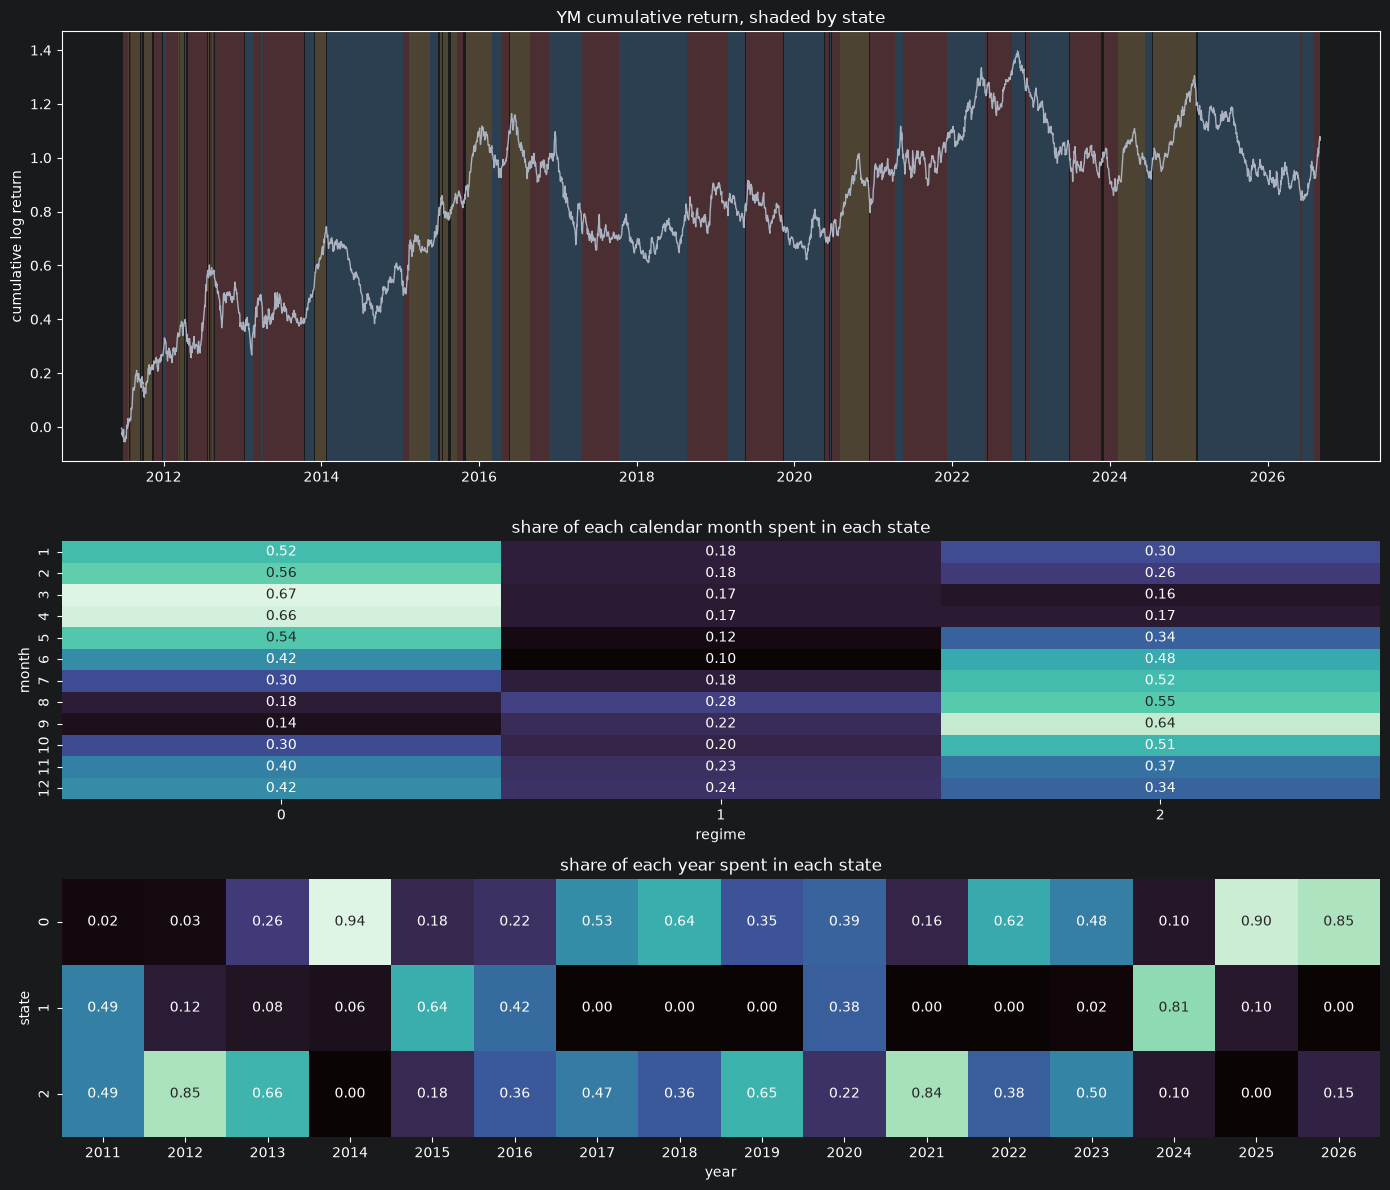

In [40]:
K = 3
REGIME_COLOURS = ["#61afef", "#e5c07b", "#e06c75", "#98c379", "#c678dd"]

fit = rg.fit_regimes(X, K, "full", n_init=20)
labels = fit["labels"]
profile = rg.profile_regimes(labels, rets, X)

display(fit["centres"].round(3))
display(profile["summary"][["n_days", "share", "ann_return", "ann_vol", "sharpe",
                            "hit_rate", "max_drawdown"]])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [2, 1.2, 1.2]})
cum = rets.reindex(labels.index).cumsum()
axes[0].plot(cum.index, cum.values, color="#abb2bf", lw=1.0)
for _, spell in labels.groupby(labels.ne(labels.shift()).cumsum()):
    axes[0].axvspan(spell.index[0], spell.index[-1],
                    color=REGIME_COLOURS[int(spell.iloc[0])], alpha=0.25, lw=0)
axes[0].set(title="YM cumulative return, shaded by state", ylabel="cumulative log return")

sns.heatmap(profile["seasonality"], annot=True, fmt=".2f", cmap="mako", ax=axes[1], cbar=False)
axes[1].set(title="share of each calendar month spent in each state", ylabel="month")

sns.heatmap(profile["occupancy_by_year"].T, annot=True, fmt=".2f", cmap="mako", ax=axes[2], cbar=False)
axes[2].set(title="share of each year spent in each state", ylabel="state")
plt.tight_layout()
plt.show()

## The one split that holds up

Two states, separated almost entirely by where local price sits in the parity band, measured over one month rather than three. Coarse, but all three clustering methods agree on it and we stay in each one for about a month at a time.

The scatter shows why it works — the separation is visible without any statistics. The heatmap beside it shows the seasonal split, and it lines up with the physical crop calendar: the loose, export-parity state dominates the harvest months, the tight, import-parity state dominates the off-season.

,log_vol,arb_pctl
regime,,
0,-1.630,0.822
1,-1.531,0.214


,n_days,share,ann_return,ann_vol,sharpe,hit_rate,max_drawdown
regime,,,,,,,
0,2109.0,0.5458,0.2126,0.2094,1.0154,0.5183,-0.2477
1,1755.0,0.4542,-0.0674,0.2334,-0.2887,0.4615,-0.6212


,n_spells,mean_length,median_length,max_length,occupancy
regime,,,,,
0,67,31.48,5.0,372,0.5458
1,67,26.19,4.0,204,0.4542


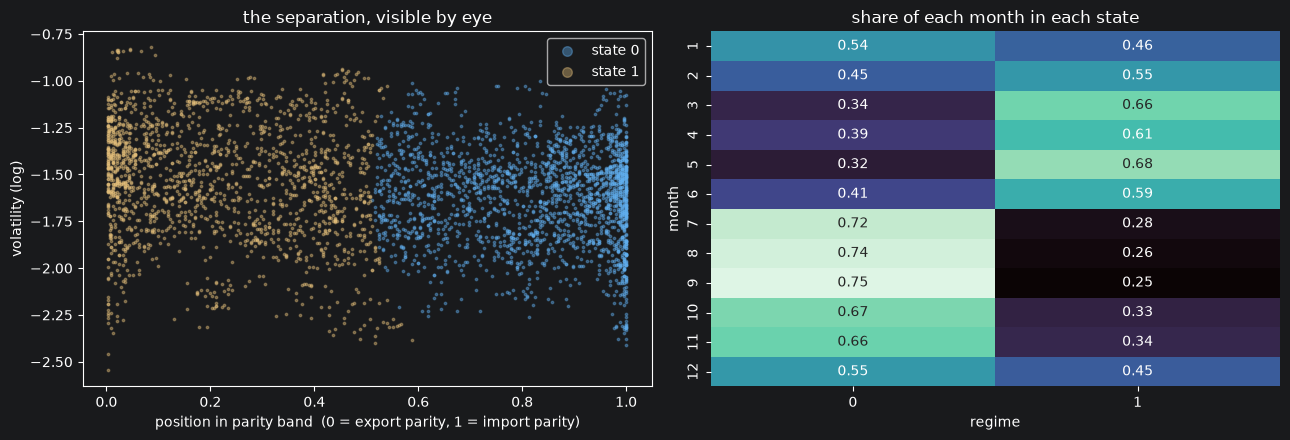

In [41]:
X_simple = rg.build_regime_features(
    df, include=("log_vol", "arb_pctl"), vol_long=21, vol_short=10, pctl_window=252
)
fit_simple = rg.fit_regimes(X_simple, 2, "full", n_init=20)
prof_simple = rg.profile_regimes(fit_simple["labels"], rets, X_simple)

display(fit_simple["centres"].round(3))
display(prof_simple["summary"][["n_days", "share", "ann_return", "ann_vol", "sharpe",
                                "hit_rate", "max_drawdown"]])
display(rg.regime_persistence(fit_simple["labels"])["per_regime"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in sorted(fit_simple["labels"].unique()):
    mask = fit_simple["labels"] == r
    axes[0].scatter(X_simple.loc[mask, "arb_pctl"], X_simple.loc[mask, "log_vol"],
                    s=3, alpha=0.4, color=REGIME_COLOURS[r], label=f"state {r}")
axes[0].set(xlabel="position in parity band  (0 = export parity, 1 = import parity)",
            ylabel="volatility (log)", title="the separation, visible by eye")
axes[0].legend(markerscale=4)
sns.heatmap(prof_simple["seasonality"], annot=True, fmt=".2f", cmap="mako", ax=axes[1], cbar=False)
axes[1].set(title="share of each month in each state", ylabel="month")
plt.tight_layout()
plt.show()

---

# What this means for the arb book

Everything above described YM on its own. YM is one leg of the arb, so the question that matters is how YM strength and weakness translate into the spread.

**The two sides.** The arb is SAFEX minus CBOT, in USD per tonne.

- **Buying the arb** — long SAFEX, short corn. Makes money when the arb **widens**. The exposed side is a sudden narrowing.
- **Selling the arb** — short SAFEX, long corn. Makes money when the arb **narrows**. The exposed side is a sudden widening.

**The key mechanism.** The arb widens when YM rallies and when CBOT falls. But how much of a YM rally leaks into the spread depends entirely on whether Chicago comes along. If YM runs and CBOT runs with it, the spread barely moves and selling it was safe. If YM runs while Chicago sits still or falls, the whole move lands on the spread.

That is the distinction the states capture, and the table below quantifies it. `corr_arb_ym` is how tightly the spread tracks YM; `corr_ym_cbot` is whether the legs move together. Read them as a pair.

The chart shows both risks side by side for each state — the chance of a move bigger than 10 USD per tonne in the next month, in each direction. A tall red bar is a bad state to be short the arb; a tall blue bar is a bad state to be long it.

,n,arb_level,ym_ann_pct,cbot_ann_pct,corr_arb_ym,corr_arb_cbot,corr_ym_cbot
key,,,,,,,
0,1547.0,21.83,-13.15,-8.66,0.46,-0.50,0.51
1,706.0,63.35,38.65,-10.70,0.63,-0.33,0.51
2,1424.0,18.95,-4.06,-3.38,0.31,-0.47,0.68


,fwd_mean,t_adj,p10_narrow,p90_widen,pct_widen,pct_narrow
key,,,,,,
0,0.21,0.16,-12.91,15.37,17.00,16.10
1,2.32,1.16,-13.48,15.44,24.36,13.60
2,1.20,0.96,-11.48,14.52,18.19,12.92


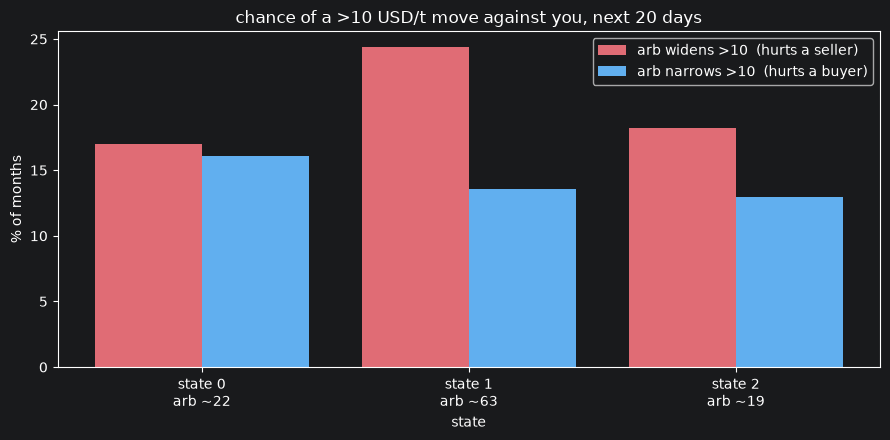

In [42]:
arb = rg.prepare_arb(df)
by_state = rg.arb_response(labels, arb)

display(by_state[["n", "arb_level", "ym_ann_pct", "cbot_ann_pct", "corr_arb_ym",
                  "corr_arb_cbot", "corr_ym_cbot"]].round(2))
display(by_state[["fwd_mean", "t_adj", "p10_narrow", "p90_widen",
                  "pct_widen", "pct_narrow"]].round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
pos = np.arange(len(by_state))
ax.bar(pos - 0.2, by_state["pct_widen"], 0.4, color="#e06c75",
       label="arb widens >10  (hurts a seller)")
ax.bar(pos + 0.2, by_state["pct_narrow"], 0.4, color="#61afef",
       label="arb narrows >10  (hurts a buyer)")
ax.set(xticks=pos, xlabel="state", ylabel="% of months",
       title="chance of a >10 USD/t move against you, next 20 days")
ax.set_xticklabels([f"state {i}\narb ~{lvl:.0f}" for i, lvl in
                    zip(by_state.index, by_state["arb_level"])])
ax.legend()
plt.tight_layout()
plt.show()

## Month by month

This is the part of the study that needs no model at all. The calendar is known in advance, so nothing here is hindsight — unlike the state labels, which we established cannot be identified live.

The top chart is the average move in the arb over the following month, by calendar month, with the whiskers showing the bad outcome on each side. Bars above the line are months the arb tends to open; bars below are months it tends to come in.

The bottom chart splits the risk by direction. Red is the chance of a big widening — the seller's problem. Blue is the chance of a big narrowing — the buyer's problem. Where the two diverge sharply is where positioning matters most.

,n,arb_level,ym_ann_pct,cbot_ann_pct,corr_arb_ym,corr_arb_cbot
key,,,,,,
1,294.0,28.58,-22.32,10.09,0.65,-0.25
2,288.0,18.36,-8.44,-13.47,0.70,-0.42
3,313.0,19.54,11.90,-1.21,0.57,-0.42
4,285.0,19.70,0.80,16.46,0.15,-0.59
5,301.0,15.30,-11.87,-7.16,0.23,-0.55
6,314.0,22.67,-26.42,-38.24,0.23,-0.51
7,339.0,34.84,26.81,-22.54,0.07,-0.61
8,321.0,36.26,-30.34,-20.29,0.36,-0.46
9,294.0,36.40,-16.22,-24.60,0.53,-0.36


,fwd_mean,t_adj,p10_narrow,p90_widen,pct_widen,pct_narrow
key,,,,,,
1,-4.50,-1.17,-22.73,14.02,15.31,34.69
2,3.61,1.03,-10.16,25.65,23.61,11.81
3,-0.87,-0.35,-12.05,10.46,11.18,11.50
4,-3.22,-1.10,-19.30,12.21,12.28,24.56
5,1.03,0.45,-9.80,11.55,12.29,9.97
6,4.33,1.65,-7.46,16.55,26.11,8.28
7,3.33,1.45,-7.23,14.31,20.35,7.37
8,-1.16,-0.47,-15.80,10.33,10.59,19.94
9,1.53,0.72,-8.30,12.85,19.39,6.80


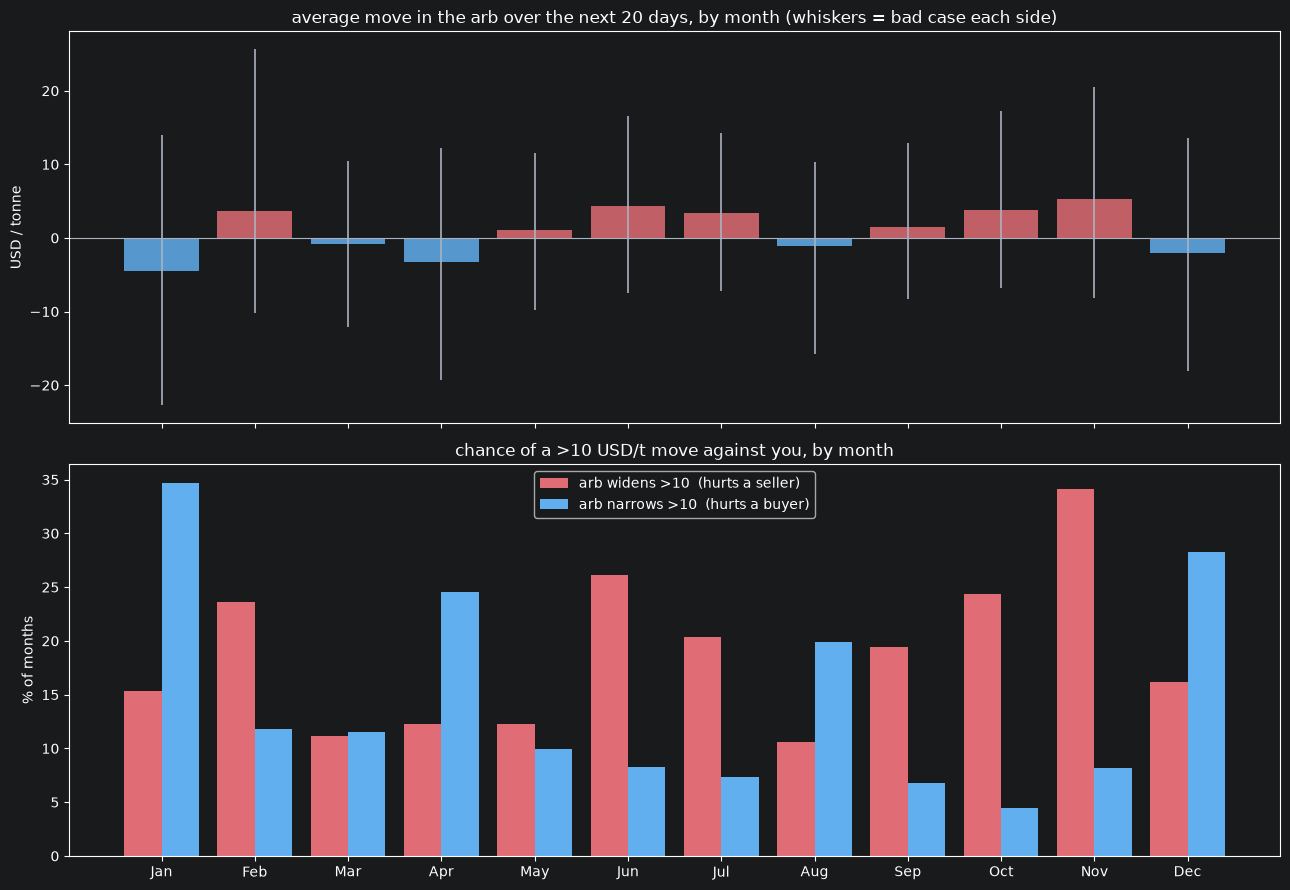

In [43]:
month = pd.Series(X.index.month, index=X.index, name="month")
by_month = rg.arb_response(month, arb)

display(by_month[["n", "arb_level", "ym_ann_pct", "cbot_ann_pct",
                  "corr_arb_ym", "corr_arb_cbot"]].round(2))
display(by_month[["fwd_mean", "t_adj", "p10_narrow", "p90_widen",
                  "pct_widen", "pct_narrow"]].round(2))

names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

colours = ["#e06c75" if v > 0 else "#61afef" for v in by_month["fwd_mean"]]
axes[0].bar(names, by_month["fwd_mean"], color=colours, alpha=0.85)
axes[0].vlines(names, by_month["p10_narrow"], by_month["p90_widen"],
               color="#abb2bf", lw=1.2)
axes[0].axhline(0, color="#abb2bf", lw=0.8)
axes[0].set(ylabel="USD / tonne",
            title="average move in the arb over the next 20 days, by month (whiskers = bad case each side)")

axes[1].bar(np.arange(12) - 0.2, by_month["pct_widen"], 0.4, color="#e06c75",
            label="arb widens >10  (hurts a seller)")
axes[1].bar(np.arange(12) + 0.2, by_month["pct_narrow"], 0.4, color="#61afef",
            label="arb narrows >10  (hurts a buyer)")
axes[1].set(xticks=np.arange(12), ylabel="% of months",
            title="chance of a >10 USD/t move against you, by month")
axes[1].set_xticklabels(names)
axes[1].legend()
plt.tight_layout()
plt.show()

## Does a wide arb come back?

The instinct when the arb reaches 60 USD is that it is historically stretched and should be faded. This checks that directly.

Every day is sorted by where the arb sat relative to its own previous three years — Q1 is the narrowest fifth of history, Q5 the widest — and we look at what the arb did over the following month. Crucially the ranking uses only past data, so this is a fair test.

If the arb mean-reverts, the bars should slope **downward**: wide arbs come back in. If it trends, they slope **upward**: wide arbs keep going.

,n,arb_level,fwd_mean,t_adj,p10_narrow,p90_widen,pct_widen,pct_narrow
key,,,,,,,,
Q1,741.0,-5.07,-1.10,-0.56,-15.24,13.59,15.25,19.16
Q2,738.0,14.76,-0.19,-0.15,-9.70,8.60,6.91,9.89
Q3,721.0,25.39,2.10,1.18,-10.46,16.22,22.75,11.10
Q4,738.0,45.15,0.17,0.09,-15.45,13.31,18.16,19.38
Q5,739.0,63.22,4.06,1.95,-12.27,19.81,31.39,12.31


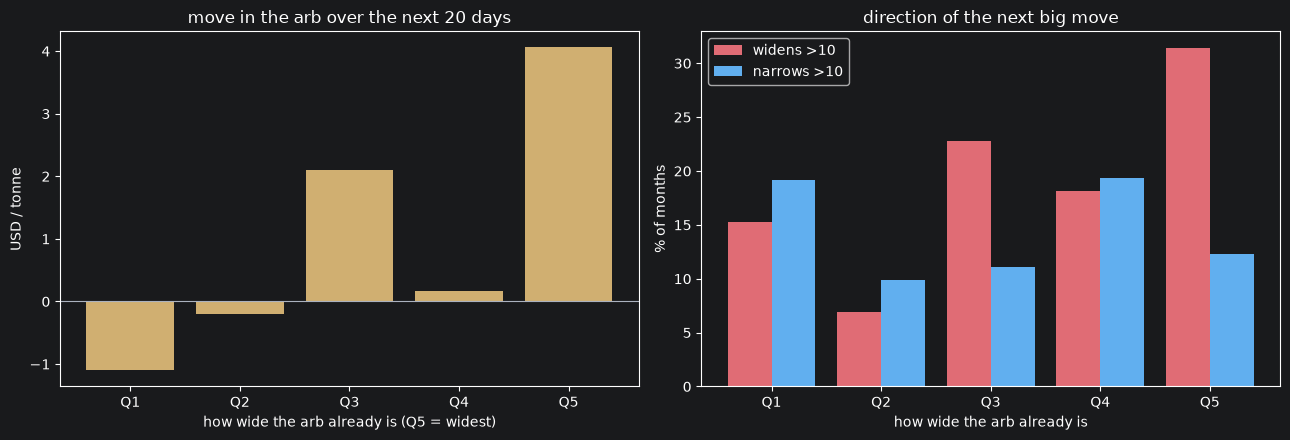

In [44]:
quintiles = rg.arb_level_quintiles(arb, X.index)
display(quintiles[["n", "arb_level", "fwd_mean", "t_adj", "p10_narrow",
                   "p90_widen", "pct_widen", "pct_narrow"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(quintiles.index.astype(str), quintiles["fwd_mean"], color="#e5c07b", alpha=0.9)
axes[0].axhline(0, color="#abb2bf", lw=0.8)
axes[0].set(ylabel="USD / tonne", xlabel="how wide the arb already is (Q5 = widest)",
            title="move in the arb over the next 20 days")

axes[1].bar(np.arange(len(quintiles)) - 0.2, quintiles["pct_widen"], 0.4,
            color="#e06c75", label="widens >10")
axes[1].bar(np.arange(len(quintiles)) + 0.2, quintiles["pct_narrow"], 0.4,
            color="#61afef", label="narrows >10")
axes[1].set(xticks=np.arange(len(quintiles)), xlabel="how wide the arb already is",
            ylabel="% of months", title="direction of the next big move")
axes[1].set_xticklabels(quintiles.index.astype(str))
axes[1].legend()
plt.tight_layout()
plt.show()

## Positioning summary

**The seasonal cycle is the usable finding.** The arb has a clear annual rhythm, and it is symmetric — the months that are dangerous for one side are comfortable for the other.

| | Jun – Nov | Dec – Apr |
|---|---|---|
| Arb tends to | **widen** | **narrow** |
| Buying the arb | favoured | exposed |
| Selling the arb | **exposed** | favoured |
| Worst single month | **November** — 34% chance of a >10 widening | **January** — 35% chance of a >10 narrowing |
| Calmest month | August — 11% widening risk, worst case only 18 | October — 4.5% narrowing risk |

**Which leg to watch changes through the year.** In December through February the arb tracks YM almost one-for-one (correlation 0.65 to 0.79) — it is a local story and YM is what to watch. From April through July that link collapses to 0.07 to 0.23 while the Chicago link strengthens to around −0.6 — the spread is being driven by corn, not by maize.

**Wide arbs do not come back — they keep going.** The widest fifth of history went on to widen by a further 4.1 USD on average, with a 31% chance of a big further widening against only 12% of a reversal. Fading a stretched arb is backwards on this sample. This is the single most actionable result in the study, and it supports exactly the caution about selling YM into strength that prompted the work.

**Three honest caveats.**

- None of the forward numbers are statistically significant once you correct for the fact that overlapping monthly windows are not independent observations. These are tendencies to size around, not signals to enter on. Each month cell holds perhaps two or three genuinely independent observations.
- The month table is clean. The state table is hindsight-labelled and should be read as a lens for understanding the mechanism, not as something to switch on live.
- Daily price limits cap the observed moves. The worst widenings on record — 35 to 42 USD — are understated, and the truncation bites hardest exactly in the tight, import-parity state where limit days cluster.

## Using the state descriptors without the states

The discrete buckets did not survive their own diagnostics, but the underlying descriptors did. Rather than asking "which of three states are we in", we can simply sort every day by where it sits on each descriptor and look at what followed. No number of states to choose, no labels to stabilise, and the ranking uses only past data.

This is the deployable form: parity-band position drives the directional tilt, volatility drives the size.

In [45]:
state = pd.DataFrame({
    "vol_pctl":      X["log_vol"].expanding(252).rank(pct=True),
    "trendiness":    X["var_ratio"].expanding(252).rank(pct=True),
    "band_position": X["arb_pctl"],
})

HORIZON = 20
fwd_ym = rets.rolling(HORIZON).sum().shift(-HORIZON + 1).reindex(X.index)

for col in state.columns:
    q = pd.qcut(state[col], 5, labels=[f"Q{i}" for i in range(1, 6)])
    g = fwd_ym.groupby(q, observed=True).agg(["mean", "std", "count"])
    g["t_adj"] = g["mean"] / g["std"] * np.sqrt(g["count"]) / np.sqrt(HORIZON)
    print(f"\n{col} — YM return over the next {HORIZON} days, by quintile")
    print(g.round(4).to_string())


vol_pctl — YM return over the next 20 days, by quintile
            mean     std  count   t_adj
vol_pctl                               
Q1        0.0076  0.0667    689  0.6693
Q2        0.0084  0.0679    689  0.7261
Q3        0.0115  0.0622    677  1.0791
Q4       -0.0014  0.0639    682 -0.1253
Q5       -0.0111  0.0595    689 -1.0974

trendiness — YM return over the next 20 days, by quintile
              mean     std  count   t_adj
trendiness                               
Q1          0.0080  0.0669    689  0.7016
Q2         -0.0013  0.0730    686 -0.1023
Q3         -0.0013  0.0594    679 -0.1260
Q4          0.0041  0.0644    683  0.3713
Q5          0.0053  0.0579    689  0.5409

band_position — YM return over the next 20 days, by quintile
                 mean     std  count   t_adj
band_position                               
Q1            -0.0035  0.0644    741 -0.3303
Q2            -0.0006  0.0576    738 -0.0587
Q3             0.0020  0.0662    721  0.1842
Q4             0.0066  